# Boston Housing - Linear Regression and Regularization



## 1. Imports and setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

print('all imports loaded')


all imports loaded


## 2. Load Data

In [2]:
# Load Boston Housing dataset from OpenML (since sklearn deprecated it)
boston = fetch_openml(name='boston', version=1, as_frame=True)
df = boston.frame.copy()

# Rename target for clarity
df.columns = [col.upper() for col in df.columns]
df = df.rename(columns={'MEDV': 'MEDV'})
df['MEDV'] = pd.to_numeric(df['MEDV'])
for col in df.columns:
    df[col] = pd.to_numeric(df[col])

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()


Dataset shape: (506, 14)
Columns: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
df.describe().round(2)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


In [4]:
print('Data types and missing values:')
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'missing': df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info_df)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')


Data types and missing values:
           dtype  missing  missing_%
CRIM     float64        0        0.0
ZN       float64        0        0.0
INDUS    float64        0        0.0
CHAS       int64        0        0.0
NOX      float64        0        0.0
RM       float64        0        0.0
AGE      float64        0        0.0
DIS      float64        0        0.0
RAD        int64        0        0.0
TAX      float64        0        0.0
PTRATIO  float64        0        0.0
B        float64        0        0.0
LSTAT    float64        0        0.0
MEDV     float64        0        0.0

Total missing values: 0


## 3. EDA (Exploratory Data Analysis)

### 3.1 Target Variable (MEDV)

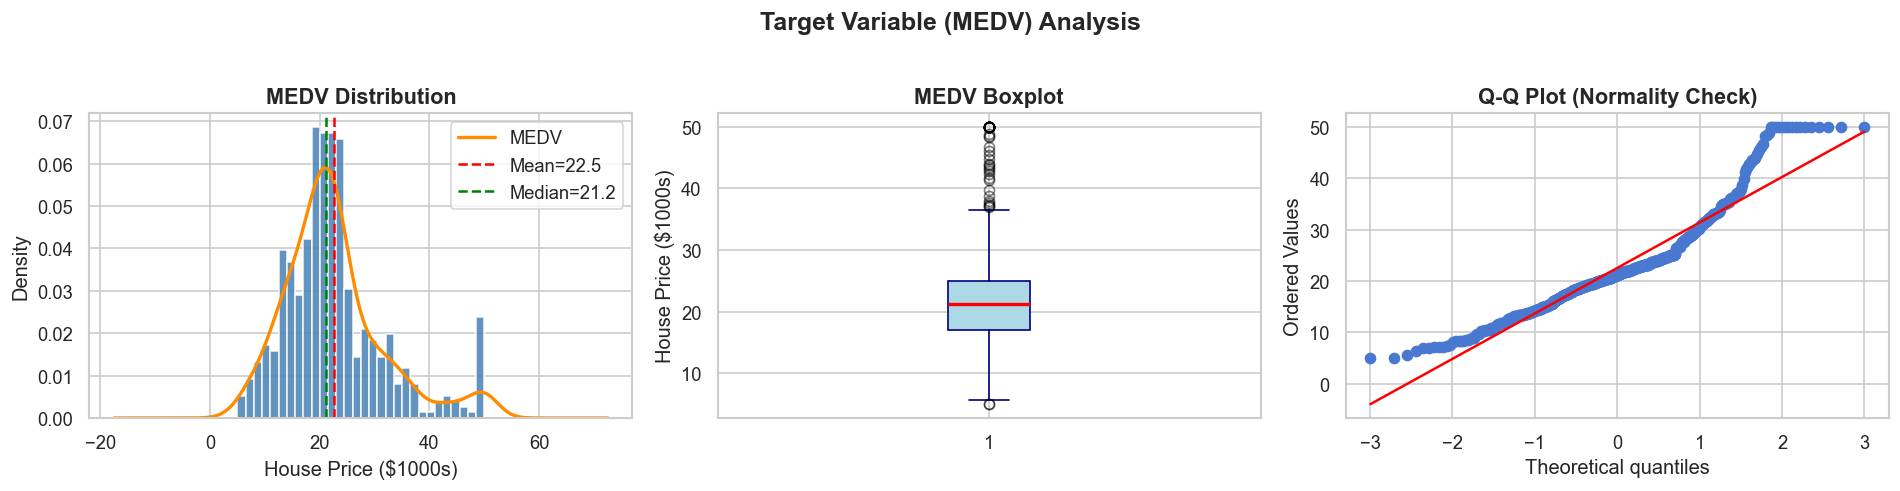

Skewness: 1.108 | Kurtosis: 1.495
Right skewed, spike at 50 is probably censored data/capped prices
The spike at 50 suggests censoring  prices were capped at $50k in data collection.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram + KDE
axes[0].hist(df['MEDV'], bins=30, color='steelblue', edgecolor='white', alpha=0.85, density=True)
df['MEDV'].plot(kind='kde', ax=axes[0], color='darkorange', linewidth=2)
axes[0].set_title('MEDV Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('House Price ($1000s)')
axes[0].set_ylabel('Density')
axes[0].axvline(df['MEDV'].mean(), color='red', linestyle='--', label=f'Mean={df["MEDV"].mean():.1f}')
axes[0].axvline(df['MEDV'].median(), color='green', linestyle='--', label=f'Median={df["MEDV"].median():.1f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['MEDV'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='navy'),
                capprops=dict(color='navy'),
                flierprops=dict(marker='o', color='red', alpha=0.5))
axes[1].set_title('MEDV Boxplot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('House Price ($1000s)')

# Q-Q Plot
stats.probplot(df['MEDV'], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)', fontsize=13, fontweight='bold')
axes[2].get_lines()[1].set_color('red')

plt.suptitle('Target Variable (MEDV) Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Skewness: {df["MEDV"].skew():.3f} | Kurtosis: {df["MEDV"].kurtosis():.3f}')
print('Right skewed, spike at 50 is probably censored data/capped prices')
print('The spike at 50 suggests censoring  prices were capped at $50k in data collection.')


### 3.2 Feature Distributions

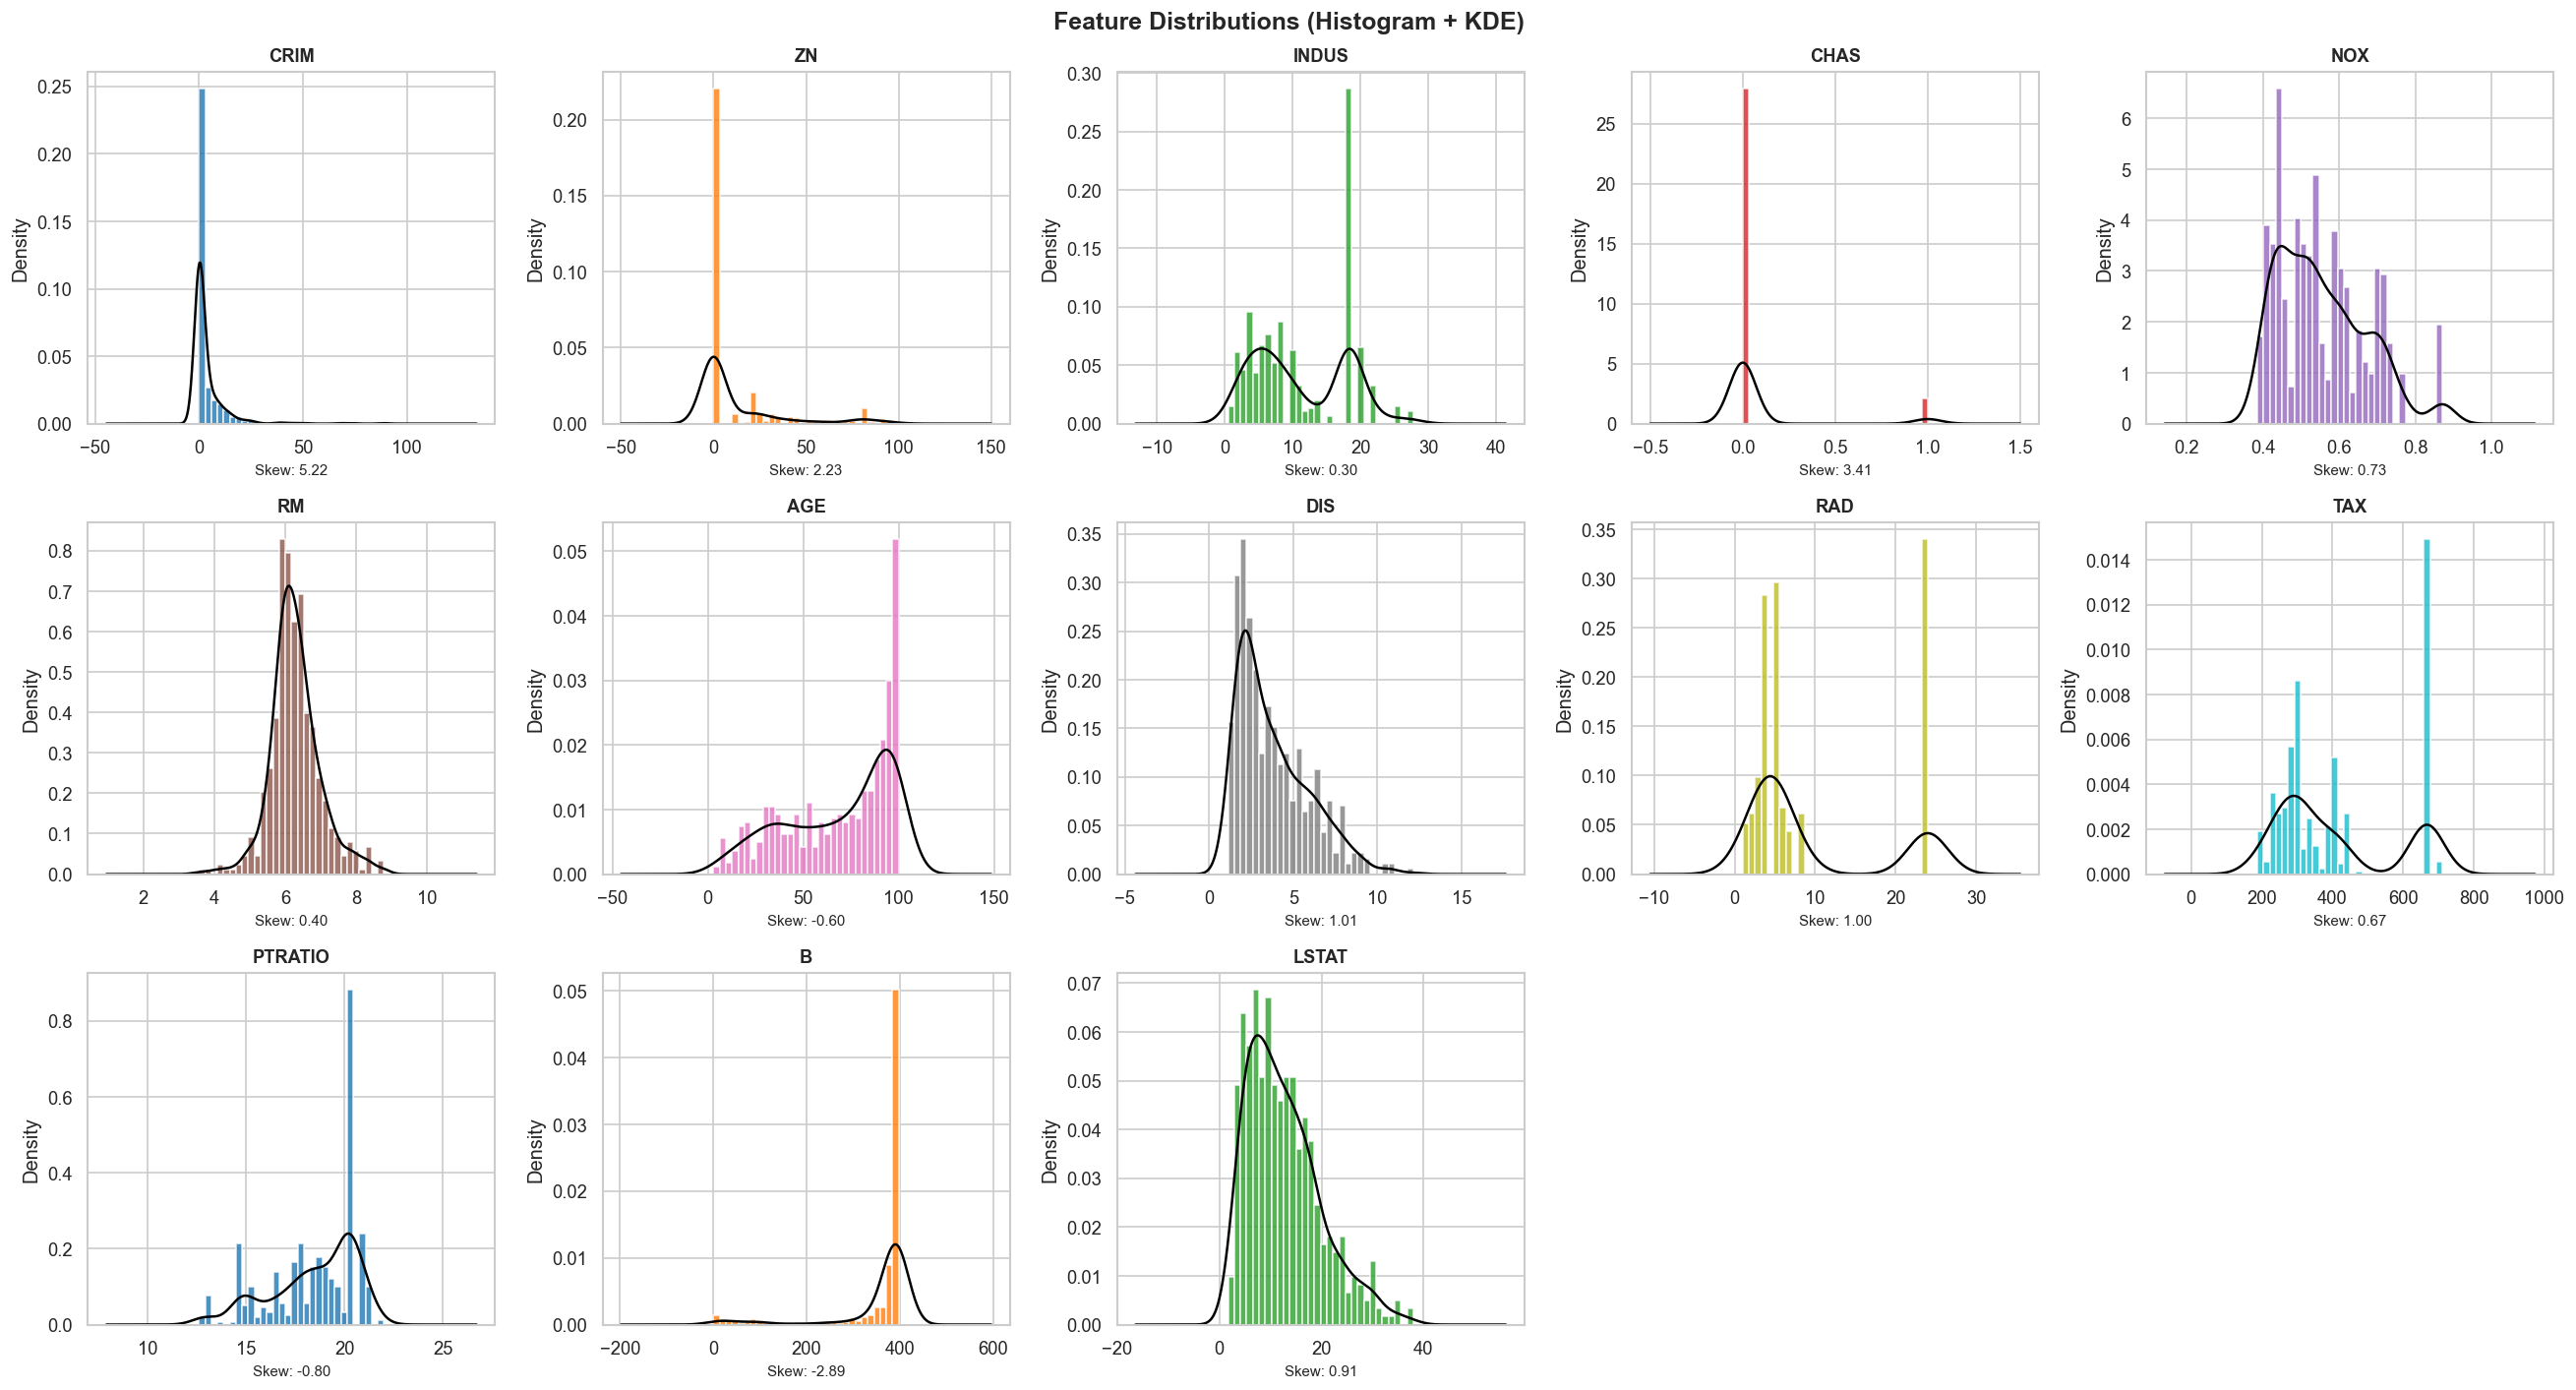

Skewness and Kurtosis summary:
         Skewness  Kurtosis
Feature                    
CRIM        5.223    37.131
CHAS        3.406     9.638
ZN          2.226     4.032
DIS         1.012     0.488
RAD         1.005    -0.867
LSTAT       0.906     0.493
NOX         0.729    -0.065
TAX         0.670    -1.142
RM          0.404     1.892
INDUS       0.295    -1.234
AGE        -0.599    -0.968
PTRATIO    -0.802    -0.285
B          -2.890     7.227


In [6]:
features = [col for col in df.columns if col != 'MEDV']

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()

colors = sns.color_palette('tab10', len(features))

for i, (col, c) in enumerate(zip(features, colors)):
    axes[i].hist(df[col], bins=30, color=c, edgecolor='white', alpha=0.8, density=True)
    df[col].plot(kind='kde', ax=axes[i], color='black', linewidth=1.5)
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Density')
    sk = df[col].skew()
    axes[i].set_xlabel(f'Skew: {sk:.2f}', fontsize=9)

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions (Histogram + KDE)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Skewness table
skew_df = pd.DataFrame({
    'Feature': features,
    'Skewness': [df[f].skew().round(3) for f in features],
    'Kurtosis': [df[f].kurtosis().round(3) for f in features]
}).set_index('Feature')
print('Skewness and Kurtosis summary:')
print(skew_df.sort_values('Skewness', ascending=False))


### 3.3 Features vs Target (MEDV)

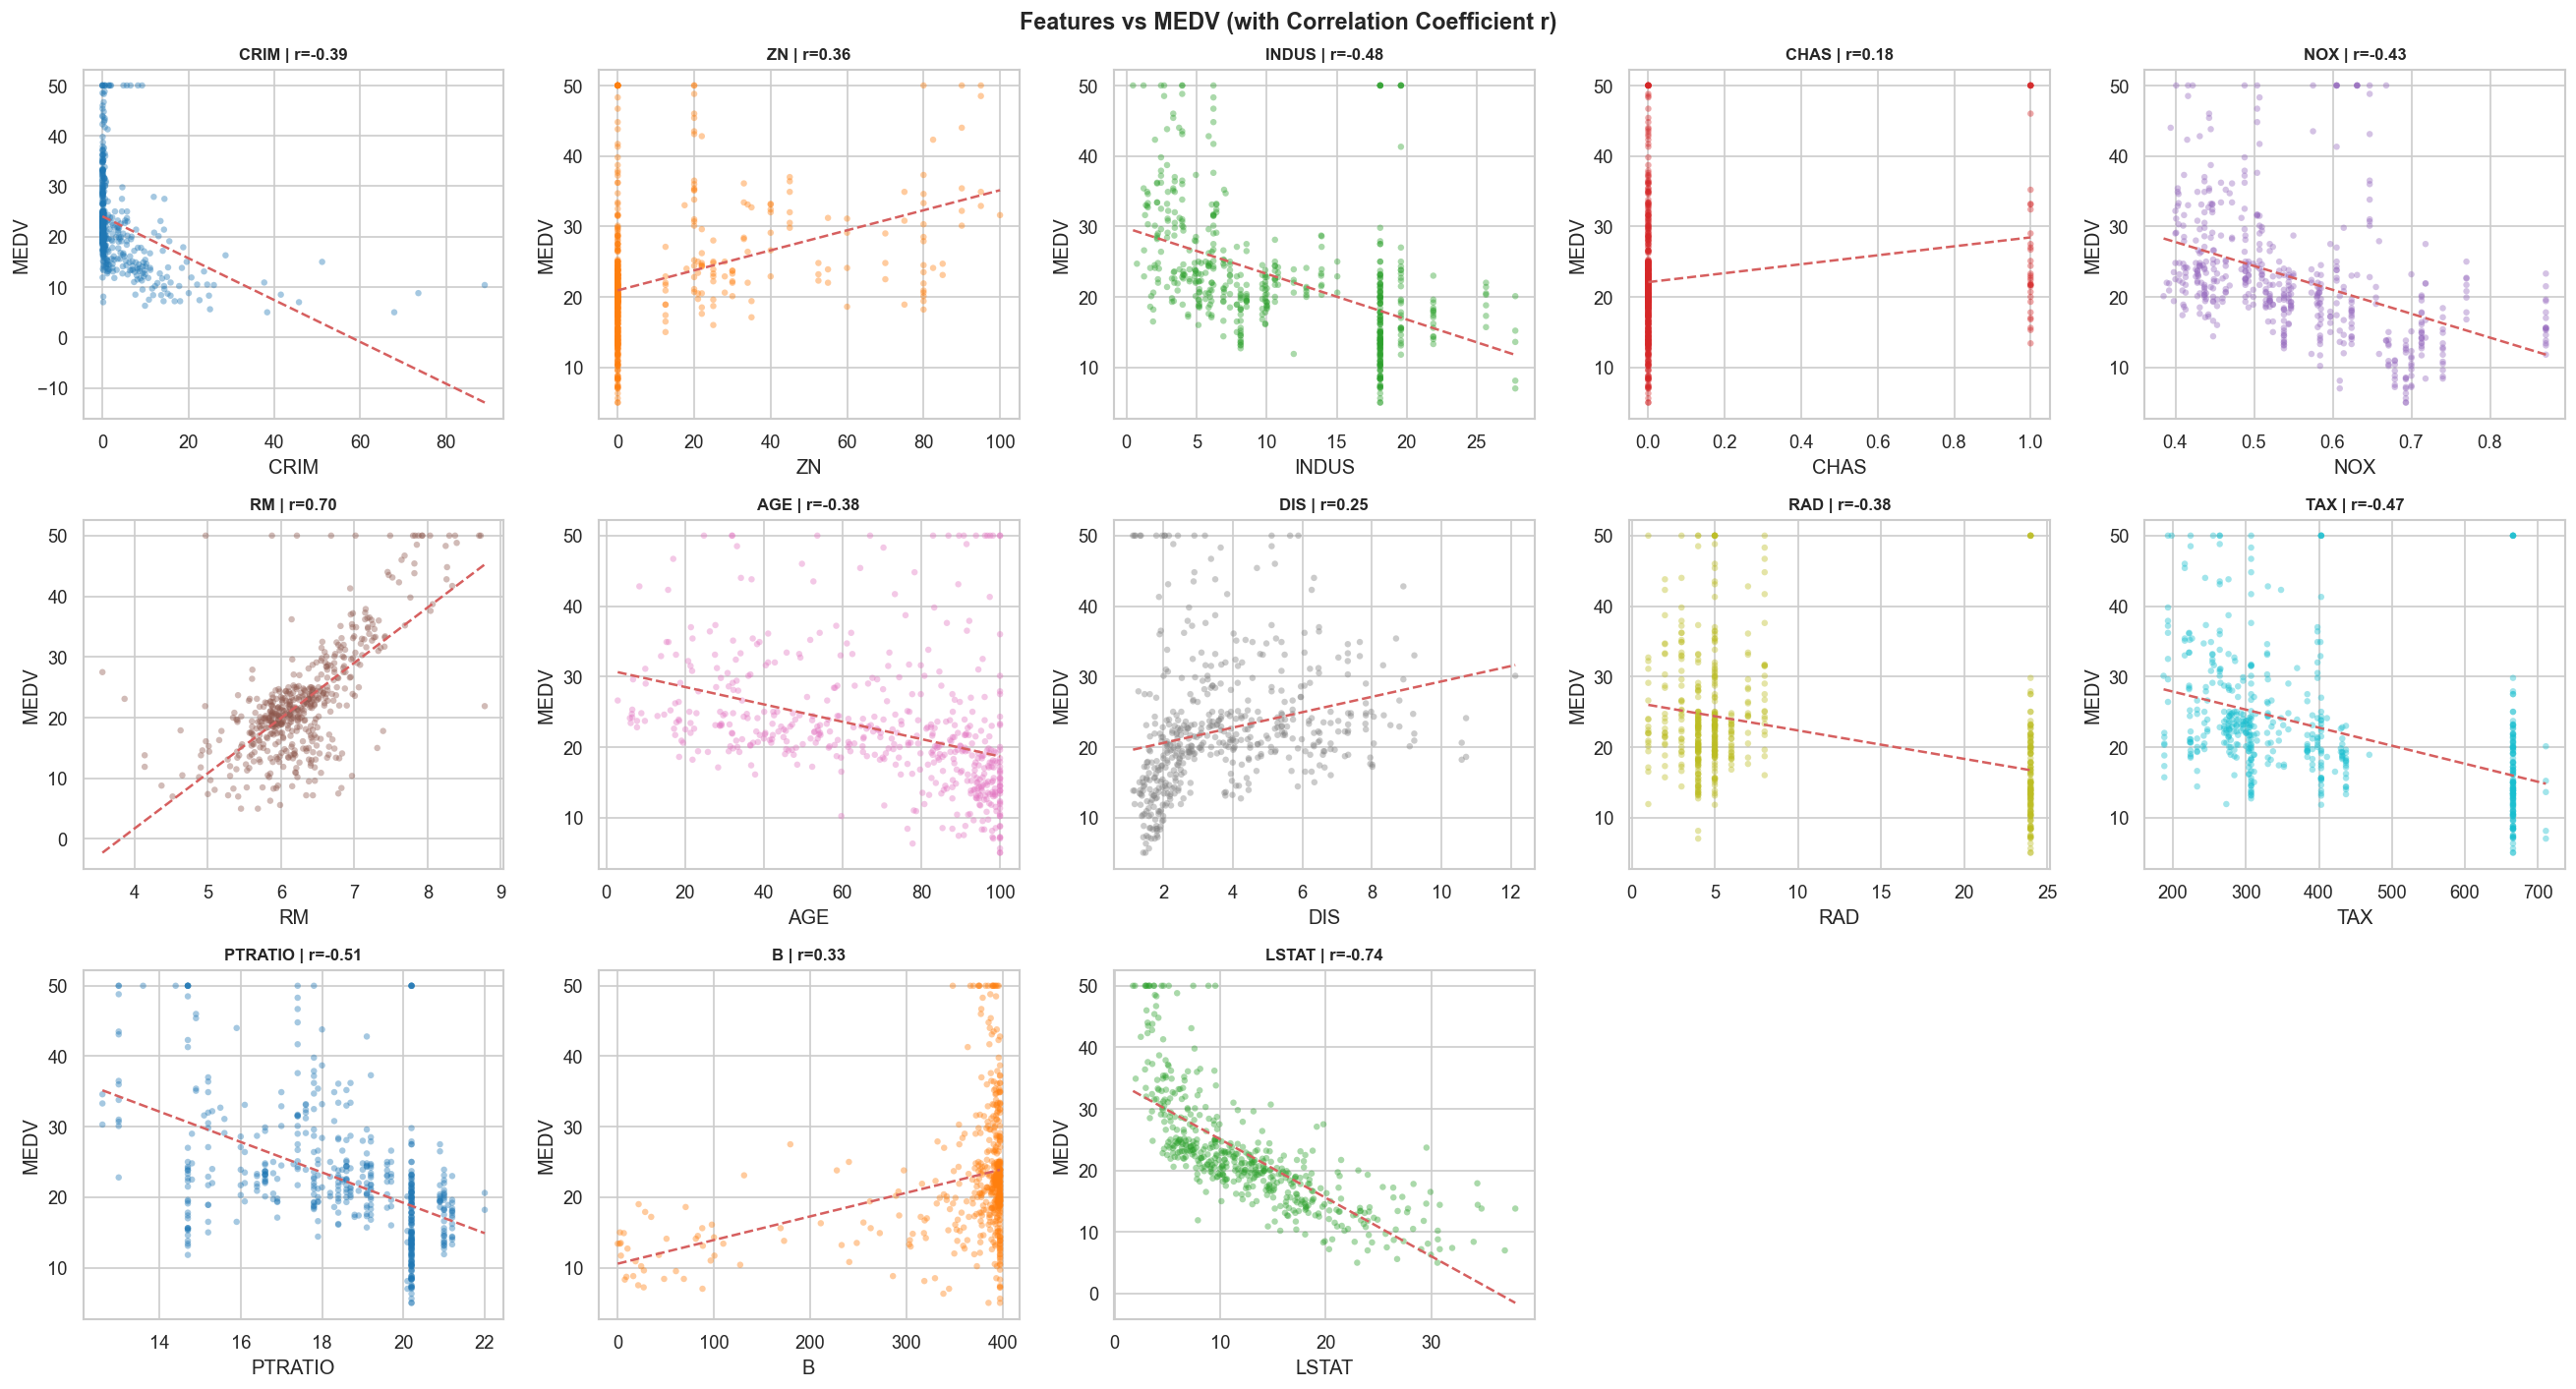

Highest correlation with MEDV:
LSTAT     -0.737663
RM         0.695360
PTRATIO   -0.507787
INDUS     -0.483725
TAX       -0.468536
NOX       -0.427321
CRIM      -0.388305
RAD       -0.381626
AGE       -0.376955
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
Name: MEDV, dtype: float64


In [7]:
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].scatter(df[col], df['MEDV'], alpha=0.4, s=15, color=colors[i], edgecolors='none')
    # Add regression line
    z = np.polyfit(df[col], df['MEDV'], 1)
    p = np.poly1d(z)
    x_sorted = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_sorted, p(x_sorted), 'r--', linewidth=1.5)
    corr = df[col].corr(df['MEDV'])
    axes[i].set_title(f'{col} | r={corr:.2f}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('MEDV')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Features vs MEDV (with Correlation Coefficient r)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Highest correlation with MEDV:')
corr_series = df.corr()['MEDV'].drop('MEDV').sort_values(key=abs, ascending=False)
print(corr_series)


### 3.4 Outlier Analysis (Boxplots)

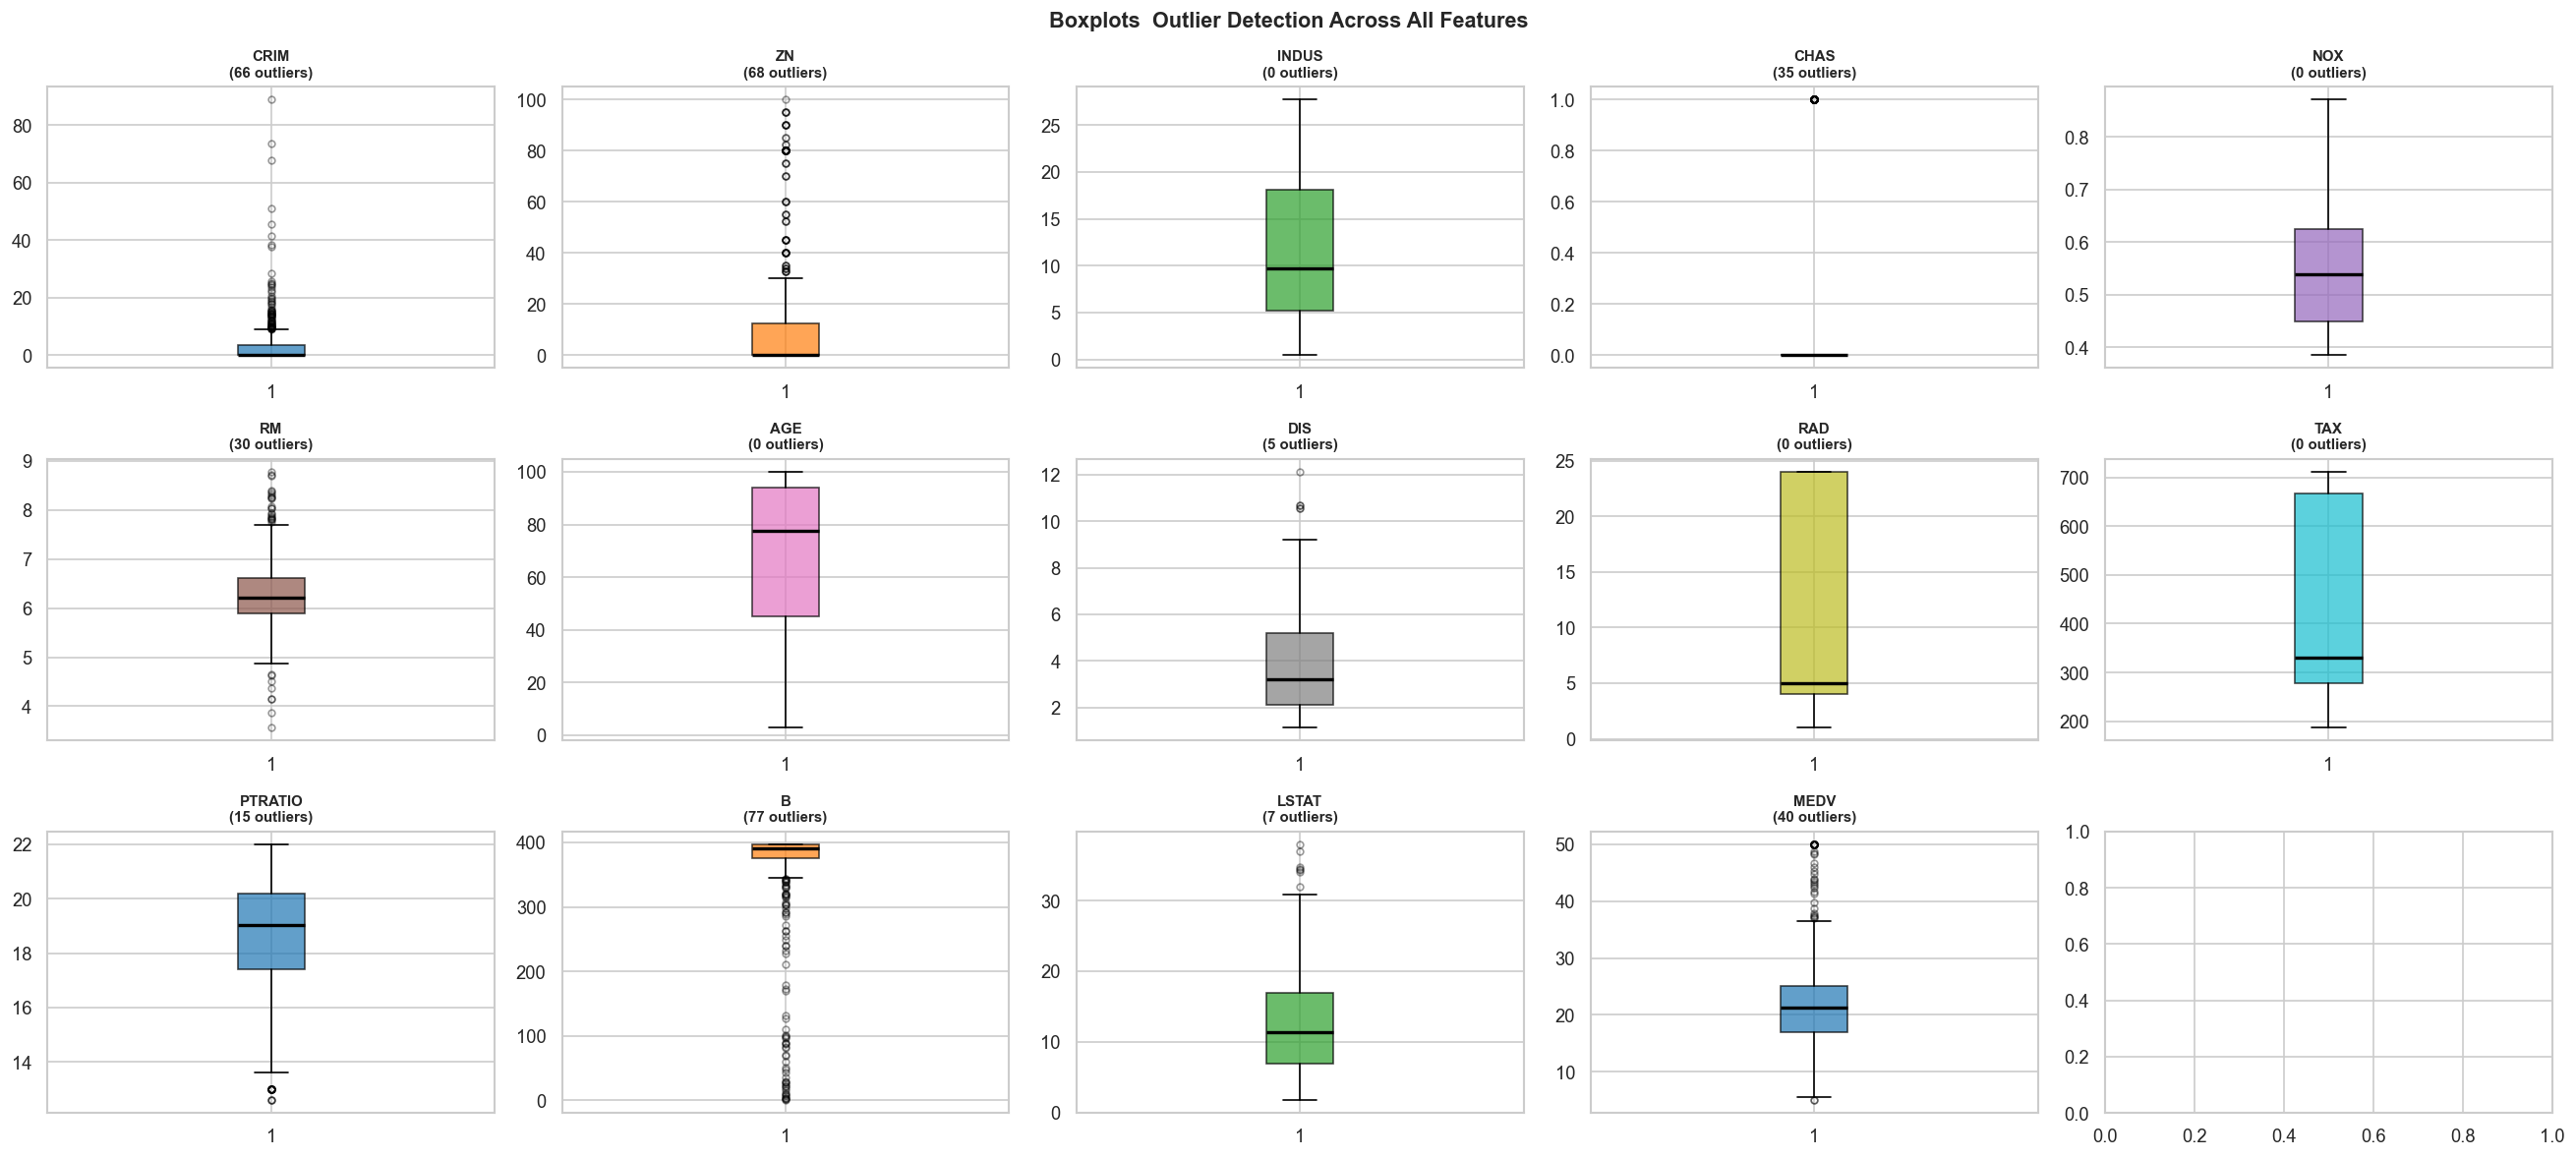

In [8]:
fig, axes = plt.subplots(3, 5, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(features + ['MEDV']):
    data = df[col]
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor=colors[i % len(colors)], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', color='red', alpha=0.4, markersize=4))
    axes[i].set_title(f'{col}\n({n_outliers} outliers)', fontsize=9, fontweight='bold')

plt.suptitle('Boxplots  Outlier Detection Across All Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.5 Correlation Matrix

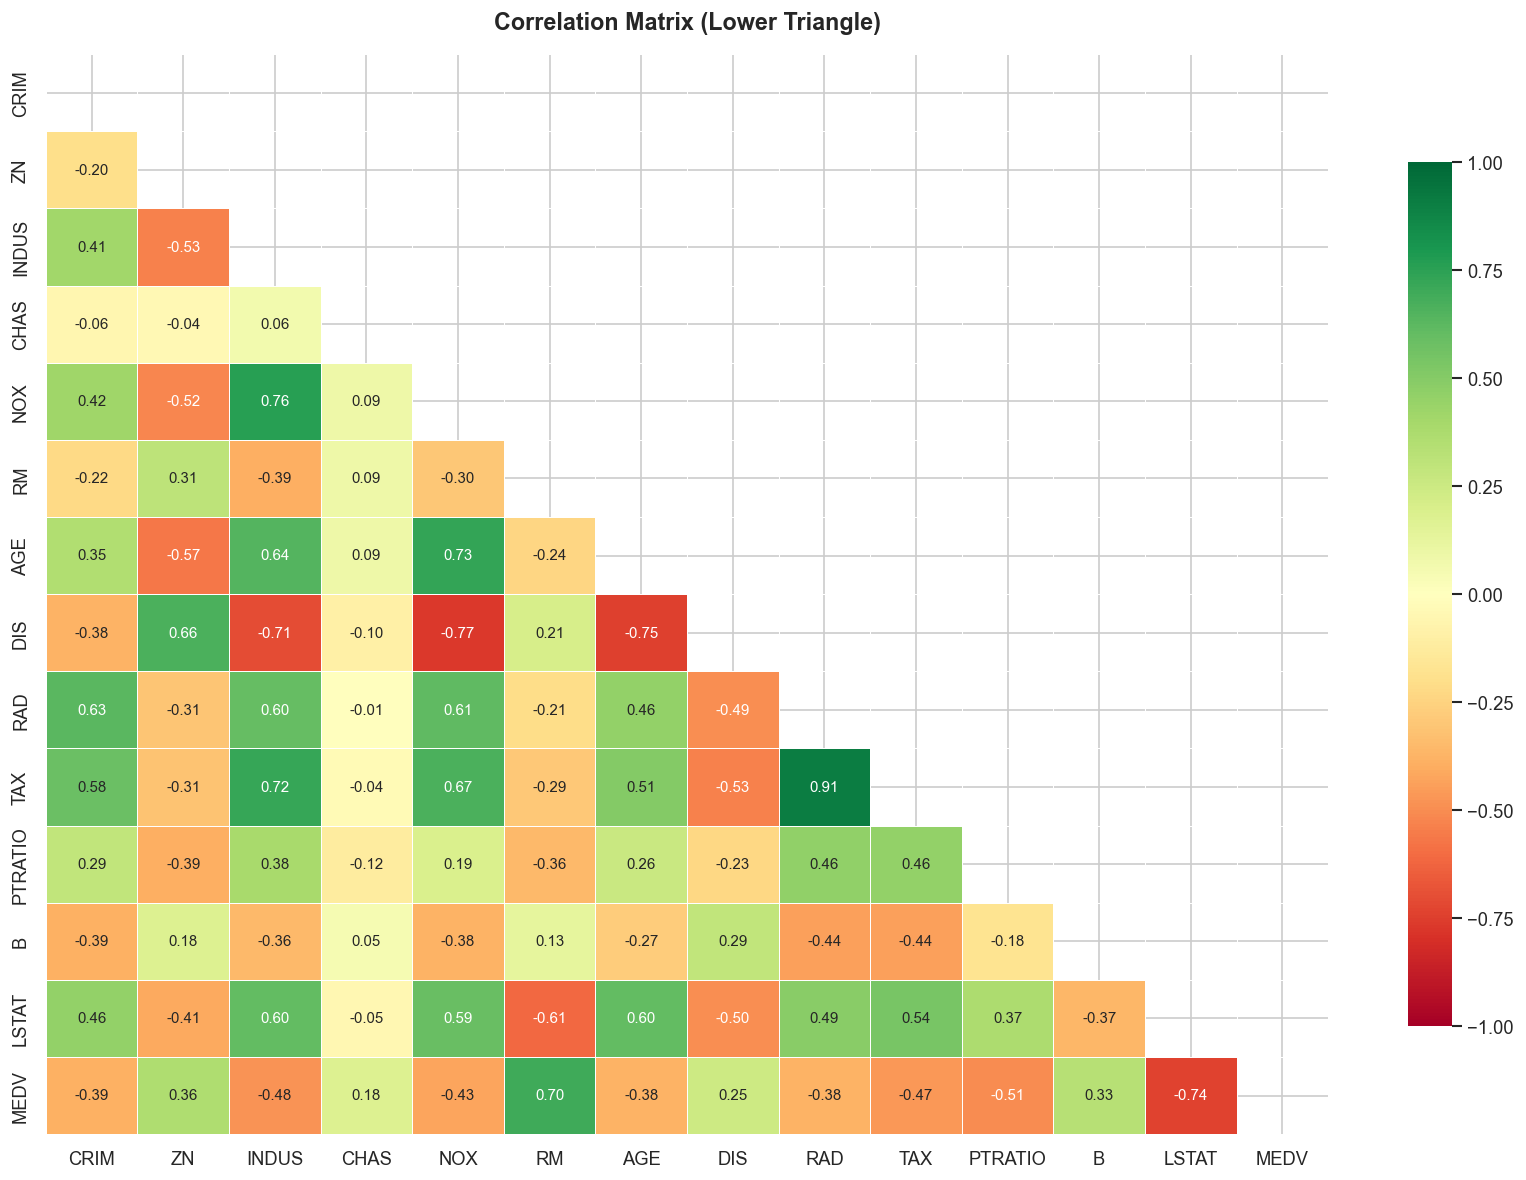


️  Highly correlated pairs (|r| > 0.7)  potential multicollinearity:
  TAX  RAD: r = 0.910
  DIS  NOX: r = -0.769
  NOX  INDUS: r = 0.764
  DIS  AGE: r = -0.748
  MEDV  LSTAT: r = -0.738
  AGE  NOX: r = 0.731
  TAX  INDUS: r = 0.721
  DIS  INDUS: r = -0.708


In [9]:
fig, ax = plt.subplots(figsize=(14, 10))

corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            annot_kws={'size': 9}, linewidths=0.5,
            ax=ax, cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Matrix (Lower Triangle)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Highlight highly correlated pairs
print('\n️  Highly correlated pairs (|r| > 0.7)  potential multicollinearity:')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
for a, b, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f'  {a}  {b}: r = {r:.3f}')


### 3.6 Pairplot of Top 5 Features

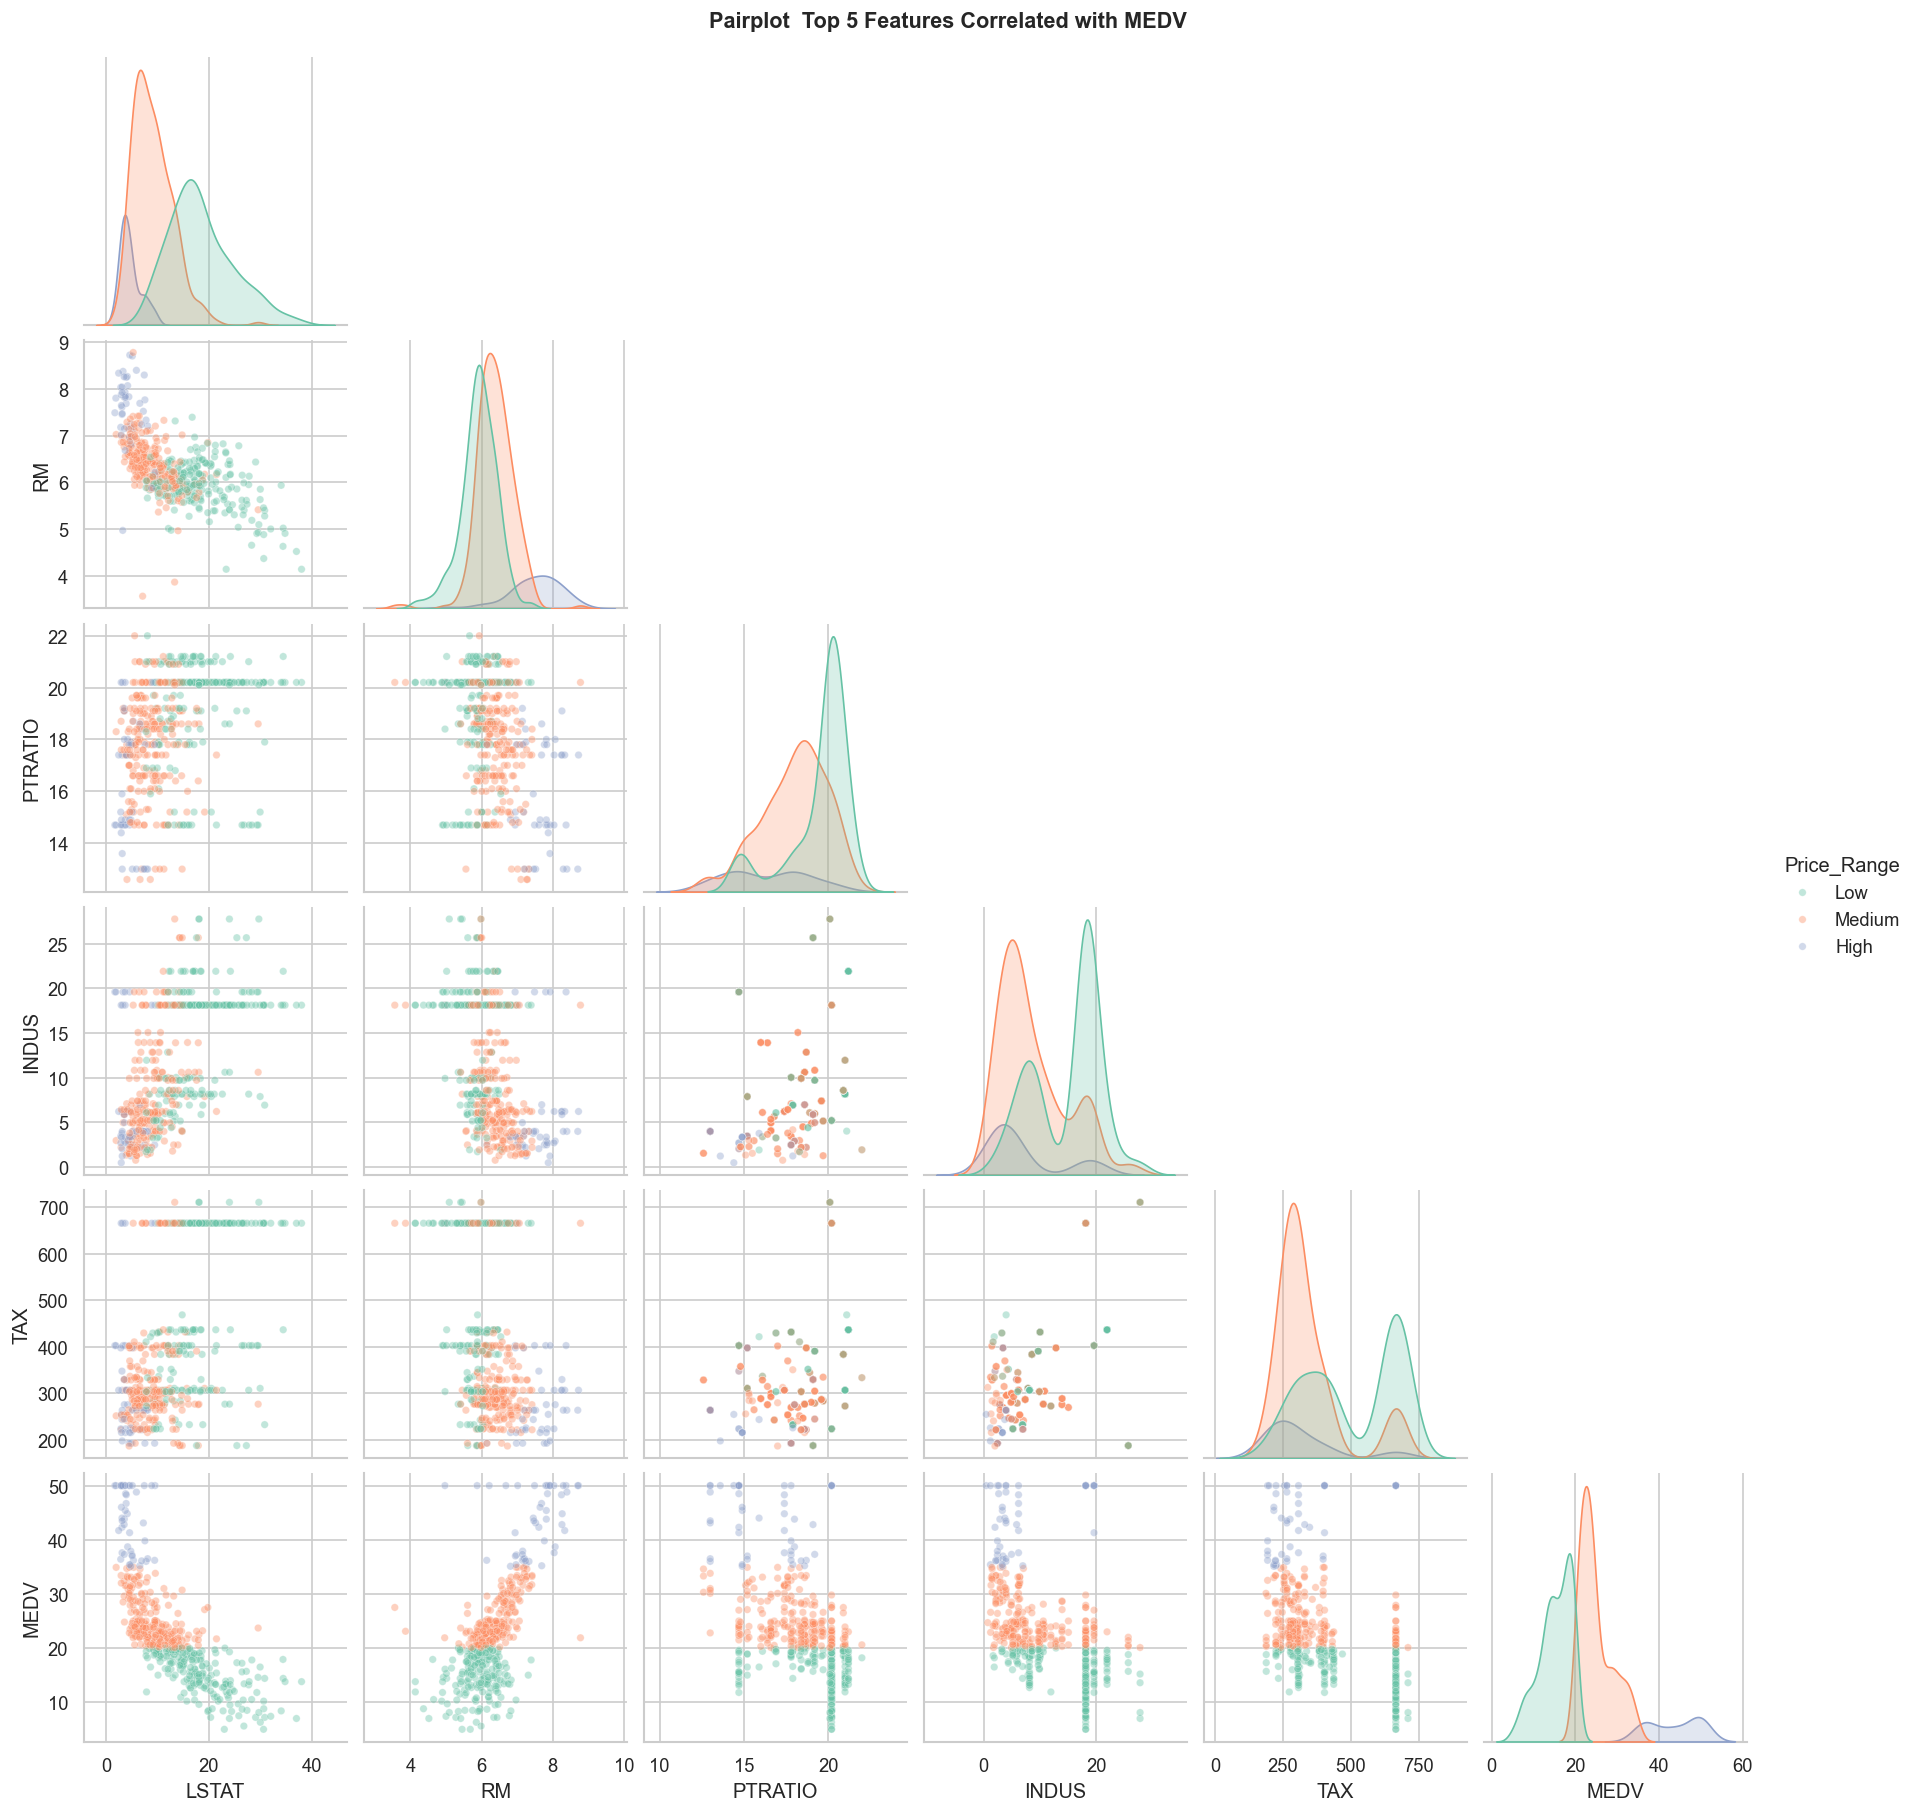

In [10]:
top5 = corr_series.abs().nlargest(5).index.tolist()
pair_df = df[top5 + ['MEDV']]

# Bin MEDV for color
pair_df = pair_df.copy()
pair_df['Price_Range'] = pd.cut(df['MEDV'], bins=3, labels=['Low', 'Medium', 'High'])

g = sns.pairplot(pair_df, hue='Price_Range', vars=top5 + ['MEDV'],
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 20},
                 palette='Set2', corner=True)
g.fig.suptitle('Pairplot  Top 5 Features Correlated with MEDV', y=1.01, fontsize=13, fontweight='bold')
plt.show()


## 4. Multicollinearity & VIF

Checking Variance Inflation Factor (VIF) to see which features are collinear.

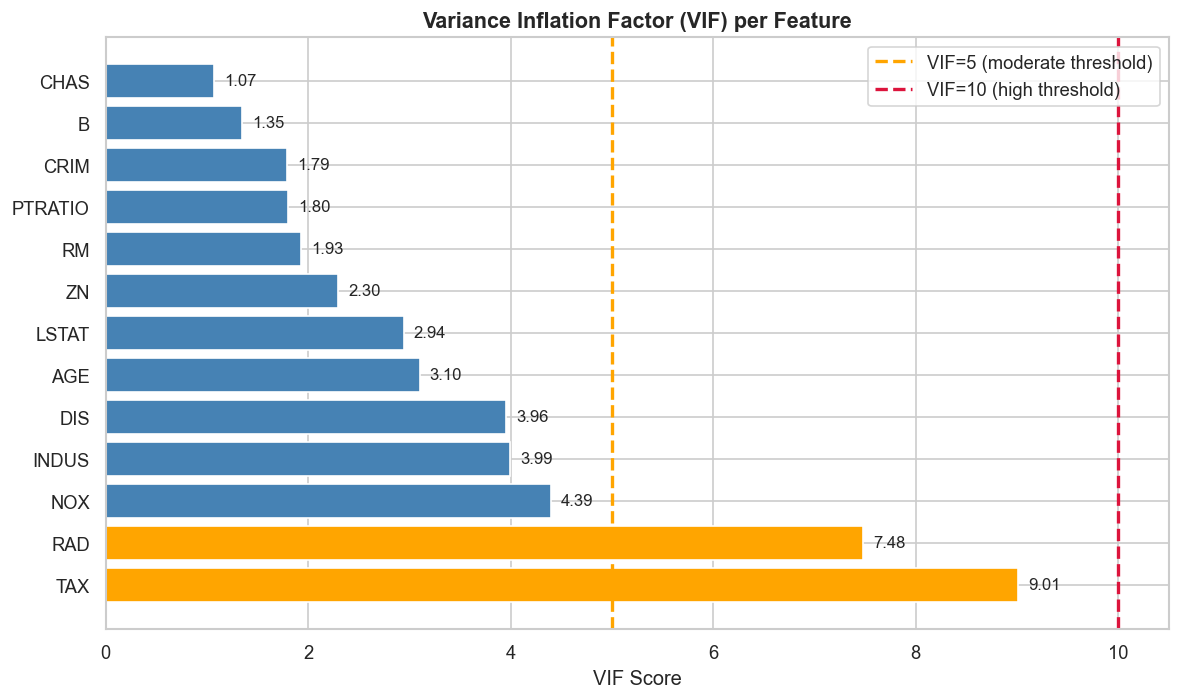

VIF values:
Feature      VIF
    TAX 9.008554
    RAD 7.484496
    NOX 4.393720
  INDUS 3.991596
    DIS 3.955945
    AGE 3.100826
  LSTAT 2.941491
     ZN 2.298758
     RM 1.933744
PTRATIO 1.799084
   CRIM 1.792192
      B 1.348521
   CHAS 1.073995

 RAD and TAX have high VIF  strong multicollinearity  drop RAD (lower R² when used alone)


In [11]:
X = df.drop(columns='MEDV')
y = df['MEDV']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['crimson' if v > 10 else 'orange' if v > 5 else 'steelblue'
              for v in vif_data['VIF']]
bars = ax.barh(vif_data['Feature'], vif_data['VIF'], color=bar_colors, edgecolor='white')
ax.axvline(5, color='orange', linestyle='--', linewidth=2, label='VIF=5 (moderate threshold)')
ax.axvline(10, color='crimson', linestyle='--', linewidth=2, label='VIF=10 (high threshold)')
for bar, v in zip(bars, vif_data['VIF']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{v:.2f}', va='center', fontsize=10)
ax.set_title('Variance Inflation Factor (VIF) per Feature', fontsize=13, fontweight='bold')
ax.set_xlabel('VIF Score')
ax.legend()
plt.tight_layout()
plt.show()

print('VIF values:')
print(vif_data.to_string(index=False))
print('\n RAD and TAX have high VIF  strong multicollinearity  drop RAD (lower R² when used alone)')


In [12]:
# drop RAD and split dataset
X = df.drop(columns=['MEDV', 'RAD'])
y = df['MEDV']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')


Train: (404, 12) | Test: (102, 12)


## 5. Linear Regression from Scratch

Writing a basic gradient descent implementation of linear regression.

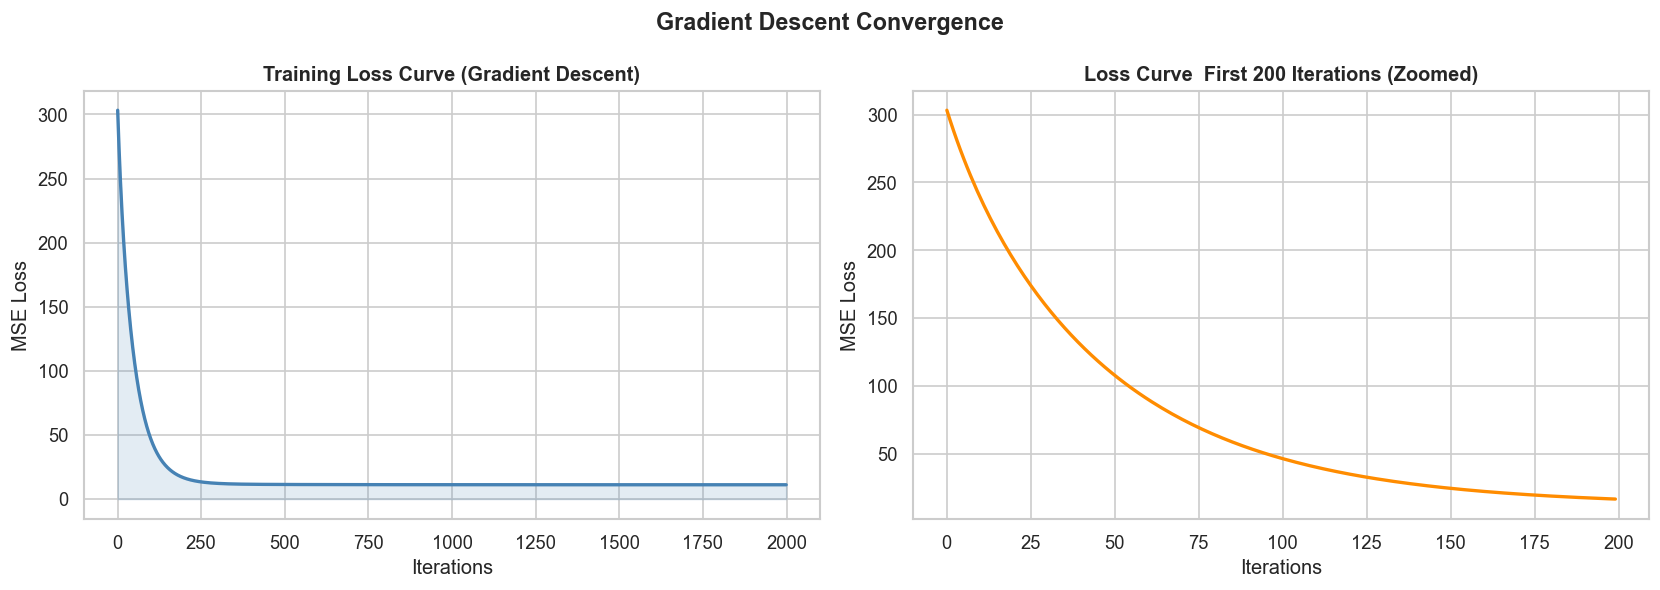

Scratch LR  R² on test: 0.6386
Scratch LR  RMSE on test: 5.1482


In [13]:
class LinearRegressionScratch:
    """Linear Regression implemented from scratch using Gradient Descent."""
    
    def __init__(self, lr=0.01, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        y = np.array(y)
        
        for _ in range(self.n_iter):
            y_pred = X @ self.weights + self.bias
            error = y_pred - y
            
            dw = (1/m) * X.T @ error
            db = (1/m) * error.sum()
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            loss = (1/(2*m)) * np.sum(error**2)
            self.loss_history.append(loss)
        
        return self
    
    def predict(self, X):
        return X @ self.weights + self.bias

# Train
lr_scratch = LinearRegressionScratch(lr=0.01, n_iter=2000)
lr_scratch.fit(X_train, y_train)

# Plot loss curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lr_scratch.loss_history, color='steelblue', linewidth=2)
axes[0].set_title('Training Loss Curve (Gradient Descent)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('MSE Loss')
axes[0].fill_between(range(len(lr_scratch.loss_history)),
                     lr_scratch.loss_history, alpha=0.15, color='steelblue')

# First 200 iterations zoomed
axes[1].plot(lr_scratch.loss_history[:200], color='darkorange', linewidth=2)
axes[1].set_title('Loss Curve  First 200 Iterations (Zoomed)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('MSE Loss')

plt.suptitle('Gradient Descent Convergence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

y_pred_scratch = lr_scratch.predict(X_test)
print(f'Scratch LR  R² on test: {r2_score(y_test, y_pred_scratch):.4f}')
print(f'Scratch LR  RMSE on test: {np.sqrt(mean_squared_error(y_test, y_pred_scratch)):.4f}')


## 6. sklearn Linear Regression

In [14]:
def adj_r2(X, y, y_pred):
    r2 = r2_score(y, y_pred)
    n, p = X.shape
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_pred_lr_train = lr.predict(X_train)

# 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, X_scaled, y, cv=kf, scoring='r2')

print('sklearn Linear Regression results:')
print(f'Train R²:          {r2_score(y_train, y_pred_lr_train):.4f}')
print(f'Test  R²:          {r2_score(y_test, y_pred_lr):.4f}')
print(f'Train Adj-R²:      {adj_r2(X_train, y_train, y_pred_lr_train):.4f}')
print(f'Test  Adj-R²:      {adj_r2(X_test, y_test, y_pred_lr):.4f}')
print(f'Train RMSE:        {np.sqrt(mean_squared_error(y_train, y_pred_lr_train)):.4f}')
print(f'Test  RMSE:        {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}')
print(f'Test  MAE:         {mean_absolute_error(y_test, y_pred_lr):.4f}')
print(f'5-Fold CV R²:      {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')


sklearn Linear Regression results:
Train R²:          0.7433
Test  R²:          0.6390
Train Adj-R²:      0.7354
Test  Adj-R²:      0.5904
Train RMSE:        4.7226
Test  RMSE:        5.1450
Test  MAE:         3.3559
5-Fold CV R²:      0.7001 ± 0.0448


### Coefficients

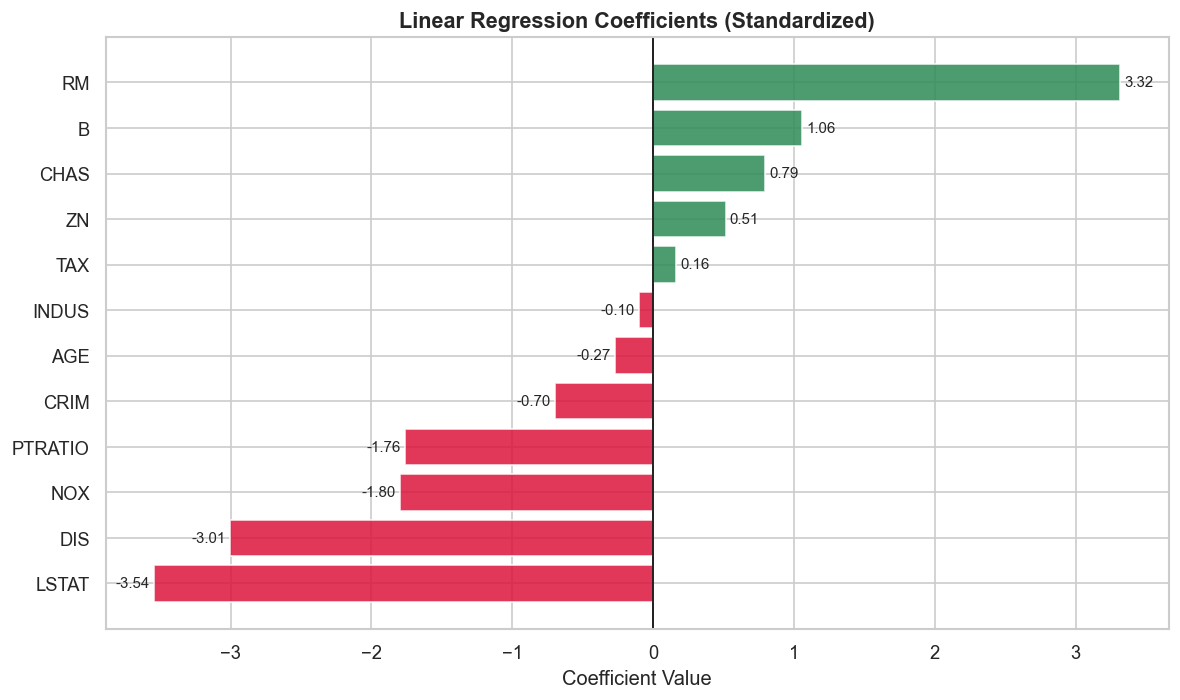

RM is the strongest positive predictor, while LSTAT and NOX are the strongest negative.


In [15]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['crimson' if c < 0 else 'seagreen' for c in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=bar_colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
for bar, v in zip(bars, coef_df['Coefficient']):
    ax.text(v + (0.03 if v >= 0 else -0.03), bar.get_y() + bar.get_height()/2,
            f'{v:.2f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)
ax.set_title('Linear Regression Coefficients (Standardized)', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print('RM is the strongest positive predictor, while LSTAT and NOX are the strongest negative.')



## 7. Regularization (Lasso, Ridge, ElasticNet)

Adding penalty terms to avoid overfitting.

### 7.1 Lasso

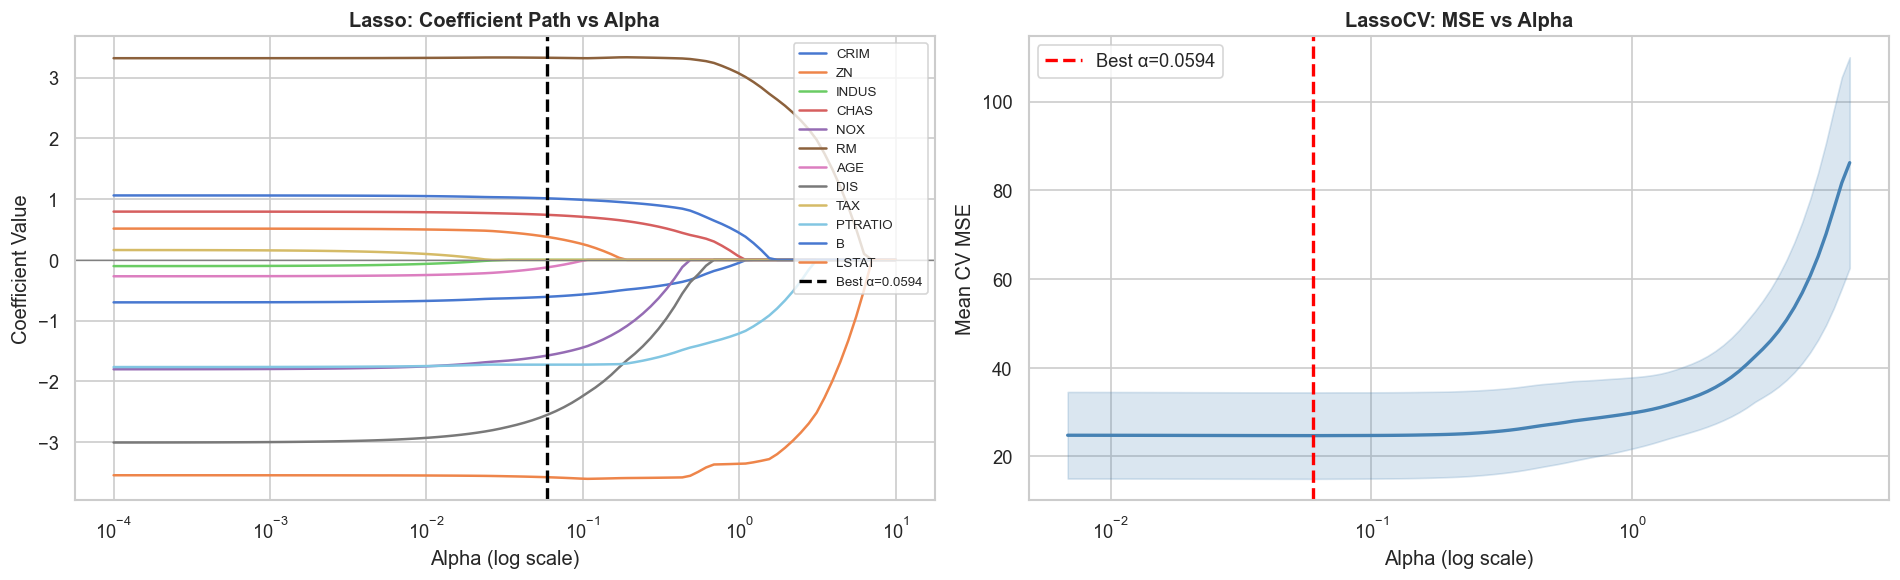

Best Lasso alpha: 0.059427
Lasso  Train R²: 0.7424 | Test R²: 0.6387
Features dropped by Lasso: 2


In [16]:
lasso_cv = LassoCV(alphas=None, cv=10, max_iter=100000)
lasso_cv.fit(X_train, y_train)
best_alpha_lasso = lasso_cv.alpha_

lasso = Lasso(alpha=best_alpha_lasso)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
y_pred_lasso_train = lasso.predict(X_train)

# Plot Lasso coefficient path
alphas_path = np.logspace(-4, 1, 100)
coef_paths = np.array([Lasso(alpha=a, max_iter=100000).fit(X_train, y_train).coef_ for a in alphas_path])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i, feat in enumerate(X.columns):
    axes[0].plot(alphas_path, coef_paths[:, i], label=feat, linewidth=1.5)
axes[0].axvline(best_alpha_lasso, color='black', linestyle='--', linewidth=2, label=f'Best α={best_alpha_lasso:.4f}')
axes[0].set_xscale('log')
axes[0].set_title('Lasso: Coefficient Path vs Alpha', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('Coefficient Value')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].axhline(0, color='gray', linewidth=0.8)

# CV scores across alphas
axes[1].semilogx(lasso_cv.alphas_, lasso_cv.mse_path_.mean(axis=-1), color='steelblue', linewidth=2)
axes[1].fill_between(lasso_cv.alphas_,
                     lasso_cv.mse_path_.mean(axis=-1) - lasso_cv.mse_path_.std(axis=-1),
                     lasso_cv.mse_path_.mean(axis=-1) + lasso_cv.mse_path_.std(axis=-1),
                     alpha=0.2, color='steelblue')
axes[1].axvline(best_alpha_lasso, color='red', linestyle='--', linewidth=2, label=f'Best α={best_alpha_lasso:.4f}')
axes[1].set_title('LassoCV: MSE vs Alpha', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('Mean CV MSE')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Best Lasso alpha: {best_alpha_lasso:.6f}')
print(f'Lasso  Train R²: {r2_score(y_train, y_pred_lasso_train):.4f} | Test R²: {r2_score(y_test, y_pred_lasso):.4f}')
print(f'Features dropped by Lasso: {(lasso.coef_ == 0).sum()}')


### 7.2 Ridge

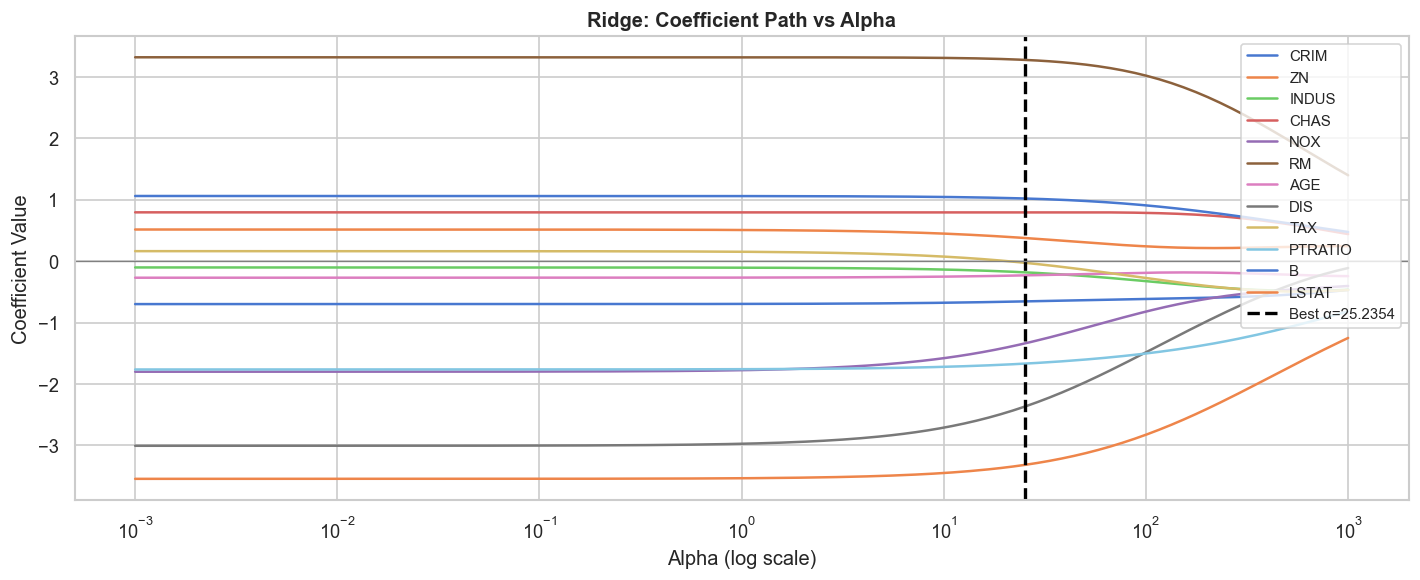

Best Ridge alpha: 25.235392
Ridge  Train R²: 0.7409 | Test R²: 0.6435


In [17]:
alphas_ridge = np.logspace(-3, 3, 200)
ridge_cv = RidgeCV(alphas=alphas_ridge, cv=10)
ridge_cv.fit(X_train, y_train)
best_alpha_ridge = ridge_cv.alpha_

ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
y_pred_ridge_train = ridge.predict(X_train)

# Ridge coefficient path
coef_paths_ridge = np.array([Ridge(alpha=a).fit(X_train, y_train).coef_ for a in alphas_ridge])

fig, ax = plt.subplots(figsize=(12, 5))
for i, feat in enumerate(X.columns):
    ax.plot(alphas_ridge, coef_paths_ridge[:, i], label=feat, linewidth=1.5)
ax.axvline(best_alpha_ridge, color='black', linestyle='--', linewidth=2, label=f'Best α={best_alpha_ridge:.4f}')
ax.set_xscale('log')
ax.set_title('Ridge: Coefficient Path vs Alpha', fontsize=12, fontweight='bold')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Coefficient Value')
ax.legend(fontsize=9, loc='upper right')
ax.axhline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.show()

print(f'Best Ridge alpha: {best_alpha_ridge:.6f}')
print(f'Ridge  Train R²: {r2_score(y_train, y_pred_ridge_train):.4f} | Test R²: {r2_score(y_test, y_pred_ridge):.4f}')


### 7.3 ElasticNet

In [18]:
en_cv = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
                     alphas=None, cv=10, max_iter=100000)
en_cv.fit(X_train, y_train)

en = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_)
en.fit(X_train, y_train)
y_pred_en = en.predict(X_test)
y_pred_en_train = en.predict(X_train)

print(f'Best ElasticNet alpha: {en_cv.alpha_:.6f}')
print(f'Best ElasticNet l1_ratio: {en_cv.l1_ratio_:.3f}')
print(f'ElasticNet  Train R²: {r2_score(y_train, y_pred_en_train):.4f} | Test R²: {r2_score(y_test, y_pred_en):.4f}')


Best ElasticNet alpha: 0.049069
Best ElasticNet l1_ratio: 0.300
ElasticNet  Train R²: 0.7421 | Test R²: 0.6416


## 8. Model Comparison

In [19]:
models = {
    'LinearRegression': (y_pred_lr_train, y_pred_lr),
    'Lasso': (y_pred_lasso_train, y_pred_lasso),
    'Ridge': (y_pred_ridge_train, y_pred_ridge),
    'ElasticNet': (y_pred_en_train, y_pred_en)
}

results = []
for name, (train_pred, test_pred) in models.items():
    results.append({
        'Model': name,
        'Train R²': round(r2_score(y_train, train_pred), 4),
        'Test R²': round(r2_score(y_test, test_pred), 4),
        'Train RMSE': round(np.sqrt(mean_squared_error(y_train, train_pred)), 4),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_test, test_pred)), 4),
        'Test MAE': round(mean_absolute_error(y_test, test_pred), 4),
        'Overfit Gap': round(r2_score(y_train, train_pred) - r2_score(y_test, test_pred), 4)
    })

results_df = pd.DataFrame(results)
print('Model results summary:')
print(results_df.to_string(index=False))


Model results summary:
           Model  Train R²  Test R²  Train RMSE  Test RMSE  Test MAE  Overfit Gap
LinearRegression    0.7433   0.6390      4.7226     5.1450    3.3559       0.1042
           Lasso    0.7424   0.6387      4.7304     5.1471    3.3150       0.1037
           Ridge    0.7409   0.6435      4.7444     5.1127    3.2607       0.0973
      ElasticNet    0.7421   0.6416      4.7336     5.1264    3.2866       0.1004


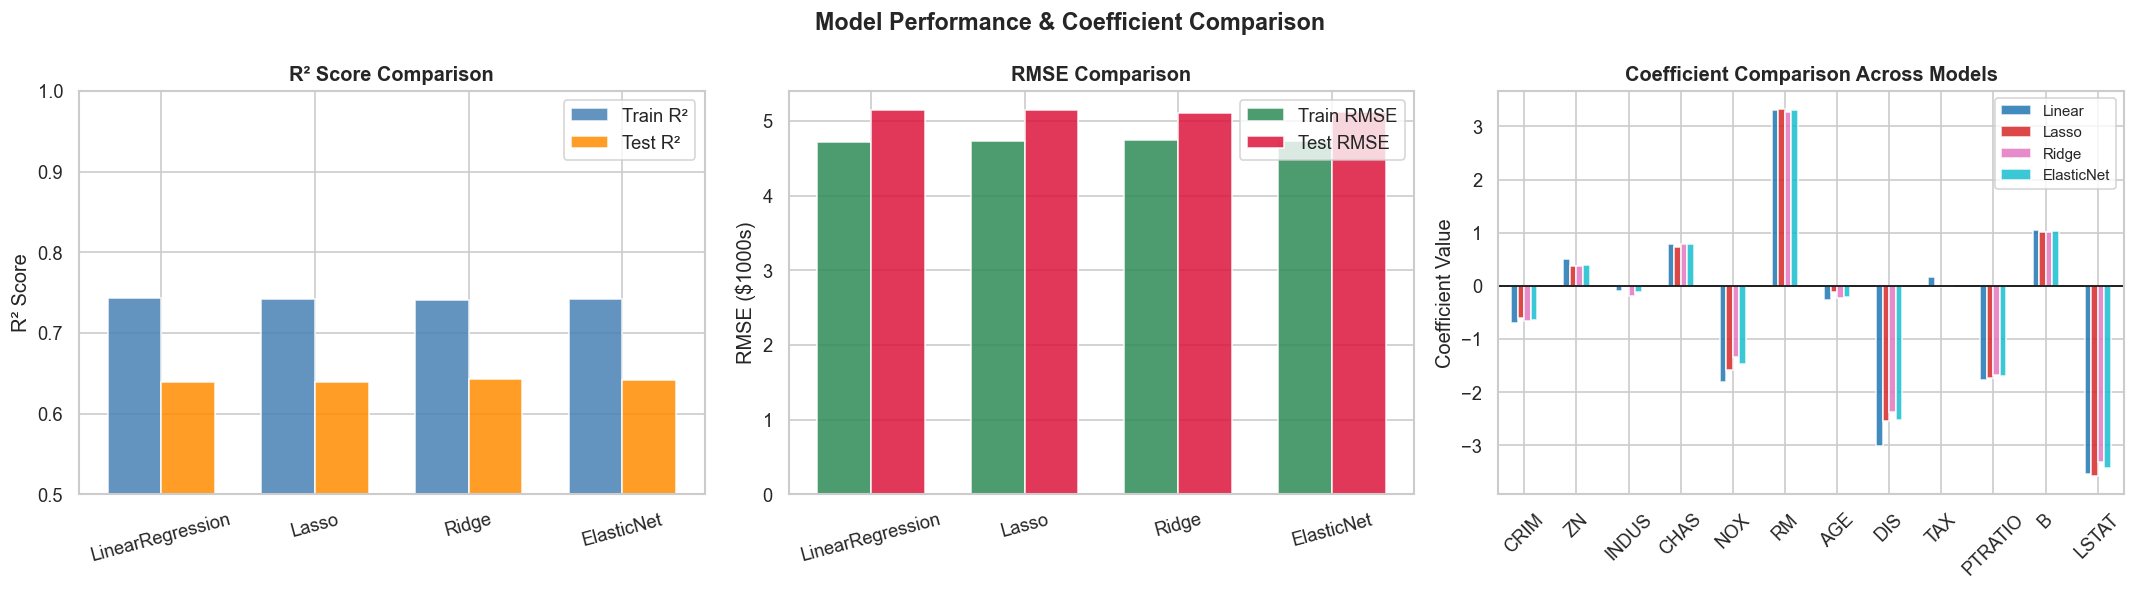

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² comparison
x = np.arange(len(results_df))
w = 0.35
axes[0].bar(x - w/2, results_df['Train R²'], width=w, label='Train R²', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, results_df['Test R²'], width=w, label='Test R²', color='darkorange', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=15)
axes[0].set_title('R² Score Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].legend()
axes[0].set_ylim(0.5, 1.0)

# RMSE comparison
axes[1].bar(x - w/2, results_df['Train RMSE'], width=w, label='Train RMSE', color='seagreen', alpha=0.85)
axes[1].bar(x + w/2, results_df['Test RMSE'], width=w, label='Test RMSE', color='crimson', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Model'], rotation=15)
axes[1].set_title('RMSE Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE ($1000s)')
axes[1].legend()

# Coefficient comparison
coef_compare = pd.DataFrame({
    'Linear': lr.coef_,
    'Lasso': lasso.coef_,
    'Ridge': ridge.coef_,
    'ElasticNet': en.coef_
}, index=X.columns)

coef_compare.plot(kind='bar', ax=axes[2], colormap='tab10', edgecolor='white', alpha=0.85)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_title('Coefficient Comparison Across Models', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Coefficient Value')
axes[2].legend(fontsize=9)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Model Performance & Coefficient Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Residual Analysis

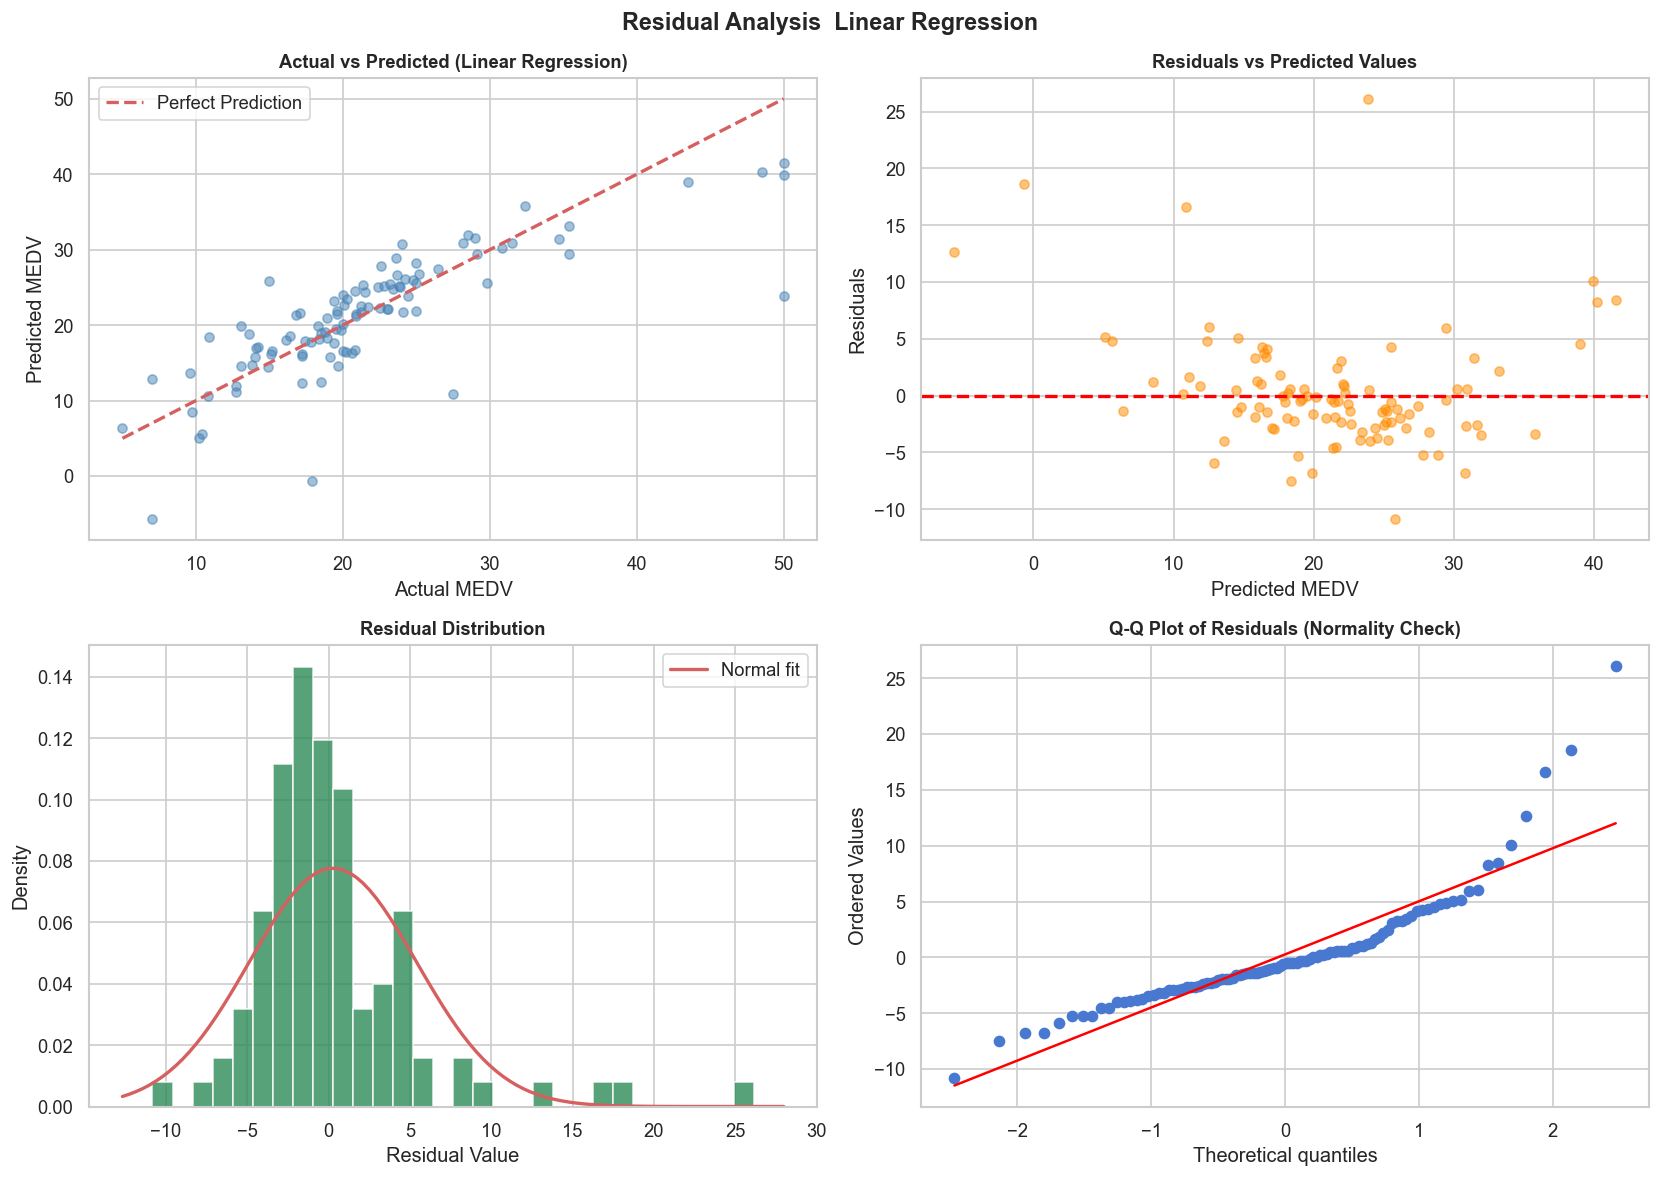

In [23]:
residuals = y_test.values - y_pred_lr

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Predicted vs Actual
axes[0, 0].scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue', s=30)
perfect = np.linspace(y_test.min(), y_test.max(), 100)
axes[0, 0].plot(perfect, perfect, 'r--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_title('Actual vs Predicted (Linear Regression)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Actual MEDV')
axes[0, 0].set_ylabel('Predicted MEDV')
axes[0, 0].legend()

# 2. Residuals vs Predicted
axes[0, 1].scatter(y_pred_lr, residuals, alpha=0.5, color='darkorange', s=30)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Residuals vs Predicted Values', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Predicted MEDV')
axes[0, 1].set_ylabel('Residuals')

# 3. Residual distribution
axes[1, 0].hist(residuals, bins=30, color='seagreen', edgecolor='white', alpha=0.8, density=True)
xmin, xmax = axes[1, 0].get_xlim()
x_norm = np.linspace(xmin, xmax, 100)
mu, std = stats.norm.fit(residuals)
axes[1, 0].plot(x_norm, stats.norm.pdf(x_norm, mu, std), 'r-', linewidth=2, label='Normal fit')
axes[1, 0].set_title('Residual Distribution', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Residual Value')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

# 4. Q-Q of residuals
stats.probplot(residuals, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals (Normality Check)', fontsize=11, fontweight='bold')
axes[1, 1].get_lines()[1].set_color('red')

plt.suptitle('Residual Analysis  Linear Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


